In [1]:
# Core libraries
import os
import random
import json
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

[HAMI-core Msg(1224:140369460768064:libvgpu.c:839)]: Initializing.....


In [2]:
# ============================================================
# Experiment configuration
# ============================================================

MODEL_NAME = "google-bert/bert-base-multilingual-cased"

NUM_LABELS = 5
MAX_LENGTH = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 10
SEED = 42

# Dataset paths relative to the classifier notebook folder
TRAIN_PATH = "../RUHSOLD_train.tsv"
VAL_PATH = "../RUHSOLD_validation.tsv"
TEST_PATH = "../RUHSOLD_test.tsv"

OUTPUT_DIR = "./outputs/mbert_baseline"

In [3]:
# ============================================================
# Load prepared RUHSOLD splits
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep="\t",
    names=["tweet", "label"]
)

val_df = pd.read_csv(
    VAL_PATH,
    sep="\t",
    names=["tweet", "label"]
)

test_df = pd.read_csv(
    TEST_PATH,
    sep="\t",
    names=["tweet", "label"]
)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Testing samples    : {len(test_df)}")

Training samples   : 6408
Validation samples : 801
Testing samples    : 2003


In [4]:
# Confirm the prepared files contain the expected five labels.
expected_labels = {0, 1, 2, 3, 4}

assert set(train_df["label"].unique()) == expected_labels
assert set(val_df["label"].unique()) == expected_labels
assert set(test_df["label"].unique()) == expected_labels

assert train_df["tweet"].notna().all()
assert val_df["tweet"].notna().all()
assert test_df["tweet"].notna().all()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# ============================================================
# Reproducibility setup
# ============================================================

import os
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """
    Set random seeds across Python, NumPy, and PyTorch.

    This reduces variation between repeated runs. Exact reproducibility
    can still depend on the GPU, CUDA version, and installed libraries.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Encourage deterministic CUDA behaviour where possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Device: cuda
GPU: NVIDIA A100 80GB PCIe
GPU memory: 16.0 GB


[HAMI-core Msg(1224:140369460768064:libvgpu.c:855)]: Initialized


In [6]:
# ============================================================
# RUHSOLD label mappings
# ============================================================

id2label = {
    0: "Abusive/Offensive",
    1: "Normal",
    2: "Religious Hate",
    3: "Sexism",
    4: "Profane"
}

label2id = {label: idx for idx, label in id2label.items()}

print("Label mapping:")
for label_id, label_name in id2label.items():
    print(f"{label_id}: {label_name}")

Label mapping:
0: Abusive/Offensive
1: Normal
2: Religious Hate
3: Sexism
4: Profane


In [7]:
# ============================================================
# Load tokenizer
# ============================================================

from transformers import AutoTokenizer

# The tokenizer must correspond to the same checkpoint used by the model.
# It converts each Roman Urdu tweet into mBERT subword token IDs.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("Model maximum length:", tokenizer.model_max_length)

Tokenizer: BertTokenizer
Vocabulary size: 119547
Model maximum length: 512


In [8]:
# ============================================================
# PyTorch dataset class for RUHSOLD
# ============================================================

from torch.utils.data import Dataset

class RUHSOLDDataset(Dataset):
    """
    PyTorch Dataset for the RUHSOLD classification task.

    Each item contains:
    - input_ids
    - attention_mask
    - label
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer,
        max_length: int
    ) -> None:
        """
        Store tweets, labels, tokenizer, and maximum sequence length.
        """
        self.tweets = dataframe["tweet"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.tweets)

    def __getitem__(self, index: int) -> dict:
        """
        Tokenize one tweet and return it with its label.
        """
        tweet = self.tweets[index]
        label = self.labels[index]

        encoded = self.tokenizer(
            tweet,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        encoded["labels"] = label

        return encoded

In [9]:
# ============================================================
# Create train, validation, and test datasets
# ============================================================

train_dataset = RUHSOLDDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = RUHSOLDDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_dataset = RUHSOLDDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"Training dataset   : {len(train_dataset)}")
print(f"Validation dataset : {len(val_dataset)}")
print(f"Testing dataset    : {len(test_dataset)}")

Training dataset   : 6408
Validation dataset : 801
Testing dataset    : 2003


In [10]:
# ============================================================
# Inspect mBERT tokenization on sample tweets
# ============================================================

sample_tweets = [
    train_df.iloc[0]["tweet"],
    "tum bohat ache insan ho",
    "yeh bohat buri aur ghatiya baat hai"
]

for tweet in sample_tweets:
    tokens = tokenizer.tokenize(str(tweet))

    print("-" * 80)
    print("Tweet :", tweet)
    print("Tokens:", tokens)
    print("Number of tokens:", len(tokens))

--------------------------------------------------------------------------------
Tweet : kia howa hai aap ko allah bless and protect you  aameen
Tokens: ['ki', '##a', 'how', '##a', 'hai', 'aa', '##p', 'ko', 'alla', '##h', 'ble', '##ss', 'and', 'protect', 'you', 'aa', '##meen']
Number of tokens: 17
--------------------------------------------------------------------------------
Tweet : tum bohat ache insan ho
Tokens: ['tu', '##m', 'bo', '##hat', 'ach', '##e', 'insan', 'ho']
Number of tokens: 8
--------------------------------------------------------------------------------
Tweet : yeh bohat buri aur ghatiya baat hai
Tokens: ['ye', '##h', 'bo', '##hat', 'bu', '##ri', 'aur', 'gh', '##ati', '##ya', 'ba', '##at', 'hai']
Number of tokens: 13


In [11]:
# ============================================================
# Dynamic batch padding
# ============================================================

from transformers import DataCollatorWithPadding

# Pad each batch only to the longest sequence within that batch.
# This is more memory-efficient than padding every tweet to MAX_LENGTH.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

In [12]:
# ============================================================
# Evaluation metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_prediction):
    """
    Compute evaluation metrics from model logits and true labels.

    Macro averaging gives equal importance to all five classes,
    which is necessary because RUHSOLD is class-imbalanced.
    """
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

In [13]:
"""# ============================================================
# Load the mBERT sequence-classification model
# ============================================================

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Model:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)"""

# ============================================================
# Reload a fresh pretrained mBERT classification model
# ============================================================

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Fresh model loaded:", model.__class__.__name__)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Fresh model loaded: BertForSequenceClassification


In [14]:
import accelerate
import transformers

print("Accelerate version :", accelerate.__version__)
print("Transformers version:", transformers.__version__)

Accelerate version : 1.14.0
Transformers version: 5.8.0


In [15]:
%pip install -U "accelerate>=1.1.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
"""from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,

    # Roughly 10% of the expected 2,403 training steps.
    warmup_steps=240,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    seed=SEED,
    data_seed=SEED,

    bf16=torch.cuda.is_available(),
    fp16=False,

    report_to="none",
    disable_tqdm=False
)

print("Training arguments created successfully.")"""

# ============================================================
# Training configuration with early stopping
# ============================================================

from transformers import TrainingArguments

EARLY_STOPPING_PATIENCE = 2

training_args = TrainingArguments(
    output_dir="./outputs/mbert_early_stopping",

    # Validate and save after every complete epoch.
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    # Keep the original fine-tuning hyperparameters unchanged.
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_steps=240,

    # Monitor validation Macro F1 and restore its best checkpoint.
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Retain only a small number of checkpoints.
    save_total_limit=2,

    # Reproducibility.
    seed=SEED,
    data_seed=SEED,

    # Mixed-precision training on the allocated GPU.
    bf16=torch.cuda.is_available(),
    fp16=False,

    report_to="none",
    disable_tqdm=False
)

print("Training arguments created successfully.")

Training arguments created successfully.


[HAMI-core Msg(1446:140035768592192:multiprocess_memory_limit.c:455)]: Calling exit handler 1446


In [17]:
"""from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

print("Trainer created successfully.")"""

# ============================================================
# Create Trainer with EarlyStoppingCallback
# ============================================================

from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,

    # Stop when validation Macro F1 has not improved for
    # two consecutive epoch-level evaluations.
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0
        )
    ]
)

print("Trainer with early stopping created successfully.")

Trainer with early stopping created successfully.


In [18]:
# ============================================================
# Train mBERT with a maximum of 10 epochs and early stopping
# ============================================================

import time

start_time = time.time()

train_result = trainer.train()

training_time_seconds = time.time() - start_time

print("\nTraining completed.")
print(f"Total training time: {training_time_seconds / 60:.2f} minutes")
print(f"Epoch reached: {trainer.state.epoch:.0f}")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print(f"Best validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.951881,0.686500,0.761548,0.676278,0.654542,0.662136,0.762921,0.761548,0.760950
2,0.610332,0.640315,0.779026,0.718889,0.686905,0.700654,0.778583,0.779026,0.777868
3,0.488095,0.803024,0.771536,0.710445,0.716661,0.706764,0.796832,0.771536,0.778086
4,0.377063,0.984197,0.766542,0.696294,0.686157,0.676082,0.781925,0.766542,0.768691
5,0.290329,1.093227,0.776529,0.687883,0.728863,0.705877,0.785695,0.776529,0.779591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Training completed.
Total training time: 3.50 minutes
Epoch reached: 5
Best checkpoint: ./outputs/mbert_early_stopping/checkpoint-2403
Best validation Macro F1: 0.7068


In [20]:
# ============================================================
# Extract clean epoch-level validation history
# ============================================================

import pandas as pd

history_df = pd.DataFrame(trainer.state.log_history)

validation_columns = [
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_macro_precision",
    "eval_macro_recall",
    "eval_macro_f1",
    "eval_weighted_precision",
    "eval_weighted_recall",
    "eval_weighted_f1"
]

# Keep only rows produced during validation.
validation_history = history_df.loc[
    history_df["eval_macro_f1"].notna(),
    validation_columns
].copy()

# Trainer may log the final evaluation more than once.
# Keep one validation record per epoch.
validation_history = (
    validation_history
    .drop_duplicates(subset=["epoch"], keep="first")
    .sort_values("epoch")
    .reset_index(drop=True)
)

validation_history

,epoch,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_precision,eval_weighted_recall,eval_weighted_f1
0,1.0,0.686500,0.761548,0.676278,0.654542,0.662136,0.762921,0.761548,0.760950
1,2.0,0.640315,0.779026,0.718889,0.686905,0.700654,0.778583,0.779026,0.777868
2,3.0,0.803024,0.771536,0.710445,0.716661,0.706764,0.796832,0.771536,0.778086
3,4.0,0.984197,0.766542,0.696294,0.686157,0.676082,0.781925,0.766542,0.768691
4,5.0,1.093227,0.776529,0.687883,0.728863,0.705877,0.785695,0.776529,0.779591


In [21]:
# ============================================================
# Save validation history and best-run summary
# ============================================================

import os
import json

RESULTS_DIR = "./outputs/mbert_early_stopping"
os.makedirs(RESULTS_DIR, exist_ok=True)

validation_history.to_csv(
    os.path.join(RESULTS_DIR, "validation_history.csv"),
    index=False
)

best_run_summary = {
    "model_name": MODEL_NAME,
    "maximum_epochs": NUM_EPOCHS,
    "epochs_completed": float(trainer.state.epoch),
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_epoch": 3,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_macro_f1": float(trainer.state.best_metric),
    "training_time_minutes": float(training_time_seconds / 60)
}

with open(
    os.path.join(RESULTS_DIR, "best_run_summary.json"),
    "w",
    encoding="utf-8"
) as file:
    json.dump(best_run_summary, file, indent=4)

print("Validation history saved.")
print("Best-run summary saved.")

Validation history saved.
Best-run summary saved.


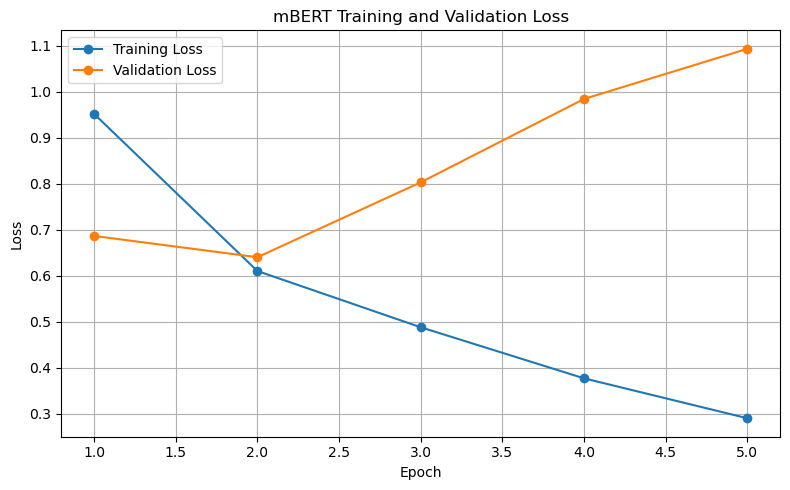

In [23]:
# ============================================================
# Plot training loss and validation loss
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Convert the Trainer log history into a DataFrame.
history_df = pd.DataFrame(trainer.state.log_history)

# Training-loss rows contain the "loss" field.
train_loss_df = history_df[
    history_df["loss"].notna()
][["epoch", "loss"]].copy()

# Validation-loss rows contain the "eval_loss" field.
val_loss_df = history_df[
    history_df["eval_loss"].notna()
][["epoch", "eval_loss"]].copy()

# Remove repeated rows that can appear after final evaluation
# or best-checkpoint restoration.
train_loss_df = train_loss_df.drop_duplicates(
    subset=["epoch"],
    keep="first"
)

val_loss_df = val_loss_df.drop_duplicates(
    subset=["epoch"],
    keep="first"
)

# Plot both curves.
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_df["epoch"],
    train_loss_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_loss_df["epoch"],
    val_loss_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("mBERT Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Generate predictions on the validation set
# ============================================================

import numpy as np

# Predict on the validation set using the best checkpoint.
validation_predictions = trainer.predict(val_dataset)

# True labels
y_true = validation_predictions.label_ids

# Predicted labels
y_pred = np.argmax(validation_predictions.predictions, axis=1)

print("Validation samples:", len(y_true))

Validation samples: 801


In [25]:
# ============================================================
# Per-class classification report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

target_names = [
    "Abusive/Offensive",
    "Normal",
    "Religious Hate",
    "Sexism",
    "Profane"
]

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Abusive/Offensive,0.606557,0.770833,0.678899,192.000000
Normal,0.930481,0.813084,0.867830,428.000000
Religious Hate,0.625000,0.793651,0.699301,63.000000
Sexism,0.830189,0.656716,0.733333,67.000000
Profane,0.560000,0.549020,0.554455,51.000000
accuracy,0.771536,0.771536,0.771536,0.771536
macro avg,0.710445,0.716661,0.706764,801.000000
weighted avg,0.796832,0.771536,0.778086,801.000000


In [26]:
# ============================================================
# Generate mBERT predictions on the validation set
# ============================================================

import numpy as np

mbert_validation_predictions = trainer.predict(val_dataset)

mbert_y_true = mbert_validation_predictions.label_ids
mbert_y_pred = np.argmax(
    mbert_validation_predictions.predictions,
    axis=1
)

print("Validation samples:", len(mbert_y_true))

Validation samples: 801


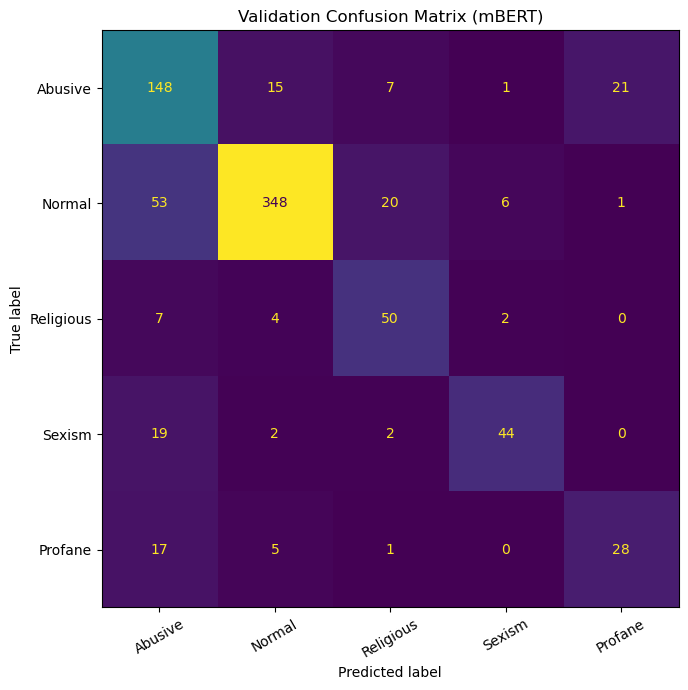

In [27]:
# ============================================================
# Plot mBERT validation confusion matrix
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane"
]

mbert_cm = confusion_matrix(
    mbert_y_true,
    mbert_y_pred,
    labels=[0, 1, 2, 3, 4]
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mbert_cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Validation Confusion Matrix (mBERT)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Save mBERT confusion matrix
# ============================================================

MBERT_RESULTS_DIR = "./outputs/mbert_early_stopping"
os.makedirs(MBERT_RESULTS_DIR, exist_ok=True)

mbert_cm_df = pd.DataFrame(
    mbert_cm,
    index=labels,
    columns=labels
)

mbert_cm_df.to_csv(
    os.path.join(
        MBERT_RESULTS_DIR,
        "validation_confusion_matrix.csv"
    )
)

fig.savefig(
    os.path.join(
        MBERT_RESULTS_DIR,
        "validation_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

print("mBERT confusion matrix saved successfully.")

mBERT confusion matrix saved successfully.
